# Final Project - Data 200

## Name : Latherine Vo

#### Loading and Inspecting Project 1 Dataset
- This section imports the required Python libraries and loads the Project 1 dataset, 
`StudentPerformanceFactors.csv`, into a pandas DataFrame. The file path is constructed 
using the `os` module to ensure the dataset is correctly located in the working directory. 
After loading the data, I inspect the distribution of the `School_Type` variable to 
understand how observations are split between public and private schools. This step 
provides an initial overview of the dataset structure and confirms that school type is 
a meaningful categorical variable for subsequent analysis.

In [36]:
import os
import pandas as pd
import numpy as np
import requests
from io import StringIO

In [ ]:
data = 'StudentPerformanceFactors.csv'
csv_path = os.path.join(os.getcwd(), '..', 'data', data)
print(csv_path)

df = pd.read_csv(data)

d:\Fall 2025\Data200\Final Project\StudentPerformanceFactors.csv


In [38]:
df['School_Type'].value_counts()

School_Type
Public     4598
Private    2009
Name: count, dtype: int64

## Web scrape/ API function

- This project uses the OECD SDMX REST API to retrieve data on average class size by type of educational institution. 
The API endpoint is structured around a dataflow identifier that specifies the education dataset, followed by 
dimension codes that define education level, institution type, frequency, and time period. These dimensions are 
encoded directly in the URL path and query parameters, allowing targeted data extraction.

- The function exploits this structure by dynamically inserting user-defined start and end years into the API query. 
This allows the function to retrieve average class size data for different time ranges, which substantially changes 
the observations returned by the API. The function requests the data in CSV format with labeled dimensions, making 
it straightforward to parse into a pandas DataFrame.

- The returned dataset contains observations across multiple countries, education levels, and institution types 
(public and private). This raw data can then be filtered and aggregated to produce tidy summaries suitable for 
comparison with student-level performance data. The function enables flexible and reproducible access to OECD 
education statistics for further analysis.

In [39]:

def get_oecd_avg_class_size(start_year, end_year):
    """
    Pull OECD average class size data by school type.
    Customizable by start and end year.
    """

    url = (
        "https://sdmx.oecd.org/public/rest/data/"
        "OECD.EDU.IMEP,DSD_EAG_UOE_NON_FIN_PERS@DF_UOE_NF_PERS_CLS,1.0/."
        "ISCED11_1+ISCED11_2......A...INST_EDU_PUB+INST_EDU_PRIV..._T."
        f"?startPeriod={start_year}&endPeriod={end_year}"
        "&format=csvfilewithlabels"
        "&dimensionAtObservation=AllDimensions"
    )

    url2 = (
        "https://sdmx.oecd.org/public/rest/data/"
        "OECD.EDU.IMEP,DSD_EAG_UOE_NON_FIN_PERS@DF_UOE_NF_PERS_CLS,1.0/."
        "......A......_T."
        f"?startPeriod={start_year}&endPeriod={end_year}"
        "&format=csvfilewithlabels"
        "&dimensionAtObservation=AllDimensions"
    )

    response = requests.get(url2)
    df_api = pd.read_csv(StringIO(response.text))

    return df_api


In [40]:
df_api = get_oecd_avg_class_size(2023, 2023)
df_api.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,EDUCATION_LEV,Education level,MEASURE,Measure,...,CONF_STATUS,Confidentiality status,COMMENT_OBS,Observation comment,DECIMALS,Decimals,TIME_PER_COLLECT,Time period collection,UNIT_MULT,Unit multiplier
0,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_UOE_NON_FIN_PERS@DF_UOE_...,Average class size,I,AUT,Austria,ISCED11_1,Primary education,CLS,Student classes,...,NaN,NaN,NaN,NaN,2,Two,NaN,NaN,0,Units
1,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_UOE_NON_FIN_PERS@DF_UOE_...,Average class size,I,AUT,Austria,ISCED11_1,Primary education,CLS,Student classes,...,NaN,NaN,NaN,NaN,2,Two,NaN,NaN,0,Units
2,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_UOE_NON_FIN_PERS@DF_UOE_...,Average class size,I,AUT,Austria,ISCED11_2,Lower secondary education,CLS,Student classes,...,NaN,NaN,NaN,NaN,2,Two,NaN,NaN,0,Units
3,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_UOE_NON_FIN_PERS@DF_UOE_...,Average class size,I,AUT,Austria,ISCED11_2,Lower secondary education,CLS,Student classes,...,NaN,NaN,NaN,NaN,2,Two,NaN,NaN,0,Units
4,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_UOE_NON_FIN_PERS@DF_UOE_...,Average class size,I,DEU,Germany,ISCED11_1,Primary education,CLS,Student classes,...,NaN,NaN,NaN,NaN,2,Two,NaN,NaN,0,Units


In [41]:
print(df_api.columns.tolist())

needed_cols = ['Type of educational institution', 'Education level', 'Reference area' ,'MEASURE', 'OBS_VALUE','TIME_PERIOD']


['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'ACTION', 'REF_AREA', 'Reference area', 'EDUCATION_LEV', 'Education level', 'MEASURE', 'Measure', 'EDUCATION_TYPE', 'Education type', 'INTENSITY', 'Intensity', 'EDUCATION_FIELD', 'Field of education', 'GRADE', 'Grade', 'FREQ', 'Frequency of observation', 'ORIGIN', 'Origin', 'DESTINATION', 'Destination', 'INST_TYPE_EDU', 'Type of educational institution', 'MOBILITY', 'Mobility', 'UNIT_MEASURE', 'Unit of measure', 'SEX', 'Sex', 'AGE', 'Age', 'TIME_PERIOD', 'Time period', 'OBS_VALUE', 'Observation value', 'REF_YEAR_AGES', 'Reference date for ages', 'ORIGIN_CRITERION', 'Origin criterion', 'REPYEARSTART', 'Reference year start', 'REPYEAREND', 'Reference year end', 'OBS_STATUS', 'Observation status', 'CONF_STATUS', 'Confidentiality status', 'COMMENT_OBS', 'Observation comment', 'DECIMALS', 'Decimals', 'TIME_PER_COLLECT', 'Time period collection', 'UNIT_MULT', 'Unit multiplier']


In [42]:
df_small = df_api[needed_cols].copy()
df_small.head(10)

,Type of educational institution,Education level,Reference area,MEASURE,OBS_VALUE,TIME_PERIOD
0,Independent private educational institutions,Primary education,Austria,CLS,NaN,2023
1,Government dependent private educational insti...,Primary education,Austria,CLS,NaN,2023
2,Government dependent private educational insti...,Lower secondary education,Austria,CLS,NaN,2023
3,Independent private educational institutions,Lower secondary education,Austria,CLS,NaN,2023
4,Government dependent private educational insti...,Primary education,Germany,CLS,NaN,2023
5,Independent private educational institutions,Primary education,Germany,CLS,NaN,2023
6,Government dependent private educational insti...,Lower secondary education,Germany,CLS,NaN,2023
7,Independent private educational institutions,Lower secondary education,Germany,CLS,NaN,2023
8,Independent private educational institutions,Primary education,Australia,CLS,NaN,2023
9,Independent private educational institutions,Lower secondary education,Australia,CLS,NaN,2023


### Conversion to Tidy Data

- The raw OECD API dataset contains multiple observations across countries, education levels, years, and types of educational institutions. To convert this dataset into a tidy format suitable for analysis, I first filtered the data to retain only observations where the measure corresponds to `Average class size` (CLS) and where the institution type is either public or private educational institutions. I then removed observations with missing values in the class size variable to ensure data quality.

- After filtering, I aggregated the data by type of educational institution and calculated the mean of the observed class size values. This aggregation collapses the dataset into one row per institution type, which aligns with the tidy data principle that each variable forms a column and each observation forms a row. Finally, I renamed variables for clarity and created a simplified `School_Type` variable to distinguish between public and private institutions. The resulting `tidy_data` contains a clear and concise summary of average class size by school type and is saved for use in subsequent visualization and analysis.


In [43]:
df_filt = df_small.loc[
    (df_small["MEASURE"] == "CLS") &
    (df_small['Type of educational institution'].isin(["Public educational institutions", "Private educational institutions"]))
]

df_filt = df_filt.dropna(subset=['OBS_VALUE'])

df_filt.head(10)

,Type of educational institution,Education level,Reference area,MEASURE,OBS_VALUE,TIME_PERIOD
109,Public educational institutions,Lower secondary education,Australia,CLS,21.69175,2023
112,Private educational institutions,Lower secondary education,Australia,CLS,18.65023,2023
114,Public educational institutions,Lower secondary education,Austria,CLS,21.35718,2023
115,Private educational institutions,Lower secondary education,Austria,CLS,21.13613,2023
116,Private educational institutions,Lower secondary education,Chile,CLS,33.08763,2023
118,Public educational institutions,Lower secondary education,Chile,CLS,29.21266,2023
121,Public educational institutions,Lower secondary education,Colombia,CLS,29.99283,2023
122,Private educational institutions,Lower secondary education,Colombia,CLS,22.26511,2023
127,Private educational institutions,Lower secondary education,Costa Rica,CLS,19.80418,2023
128,Public educational institutions,Lower secondary education,Costa Rica,CLS,30.54614,2023


In [44]:
tidy_data = df_filt.groupby('Type of educational institution')['OBS_VALUE'].agg('mean')
#tidy_data.rename(columns={'OBS_VALUE':"Average class size"}, inplace = True)

tidy_data = tidy_data.reset_index()

tidy_data.head()

,Type of educational institution,OBS_VALUE
0,Private educational institutions,20.068596
1,Public educational institutions,21.869572


In [45]:
tidy_data=tidy_data.rename(columns={'OBS_VALUE':"Average class size"})

tidy_data['School_Type'] = tidy_data['Type of educational institution'].replace({'Public educational institutions': 'Public', 'Private educational institutions': 'Private'})

tidy_data.head()

,Type of educational institution,Average class size,School_Type
0,Private educational institutions,20.068596,Private
1,Public educational institutions,21.869572,Public


In [46]:
tidy_data.to_csv('oecd_class_size_by_school_type_api.csv')

### Extracted Data Visualization 

- The first visualization presents a bar chart comparing the average class size of public and private educational institutions using OECD data from 2023. The results show that public institutions have a larger average class size (approximately 21.9 students per class) than private institutions (approximately 20.1 students per class). This suggests that, on average, classrooms in public schools tend to include more students than those in private schools across OECD countries.

- The second visualization displays the same information using a dot plot, which emphasizes the magnitude of the difference between school types. Although the difference in average class size is modest, the separation between public and private institutions is clearly visible. Presenting the data in two complementary formats reinforces the observed pattern and confirms that public schools consistently operate with slightly larger class sizes. These extracted visualizations provide important contextual information that can help interpret differences in student performance observed in subsequent analyses.

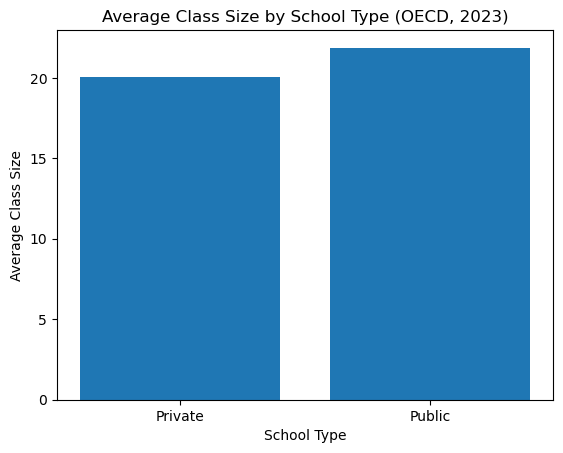

In [47]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(
    tidy_data["School_Type"],
    tidy_data["Average class size"]
)
plt.xlabel("School Type")
plt.ylabel("Average Class Size")
plt.title("Average Class Size by School Type (OECD, 2023)")
plt.show()


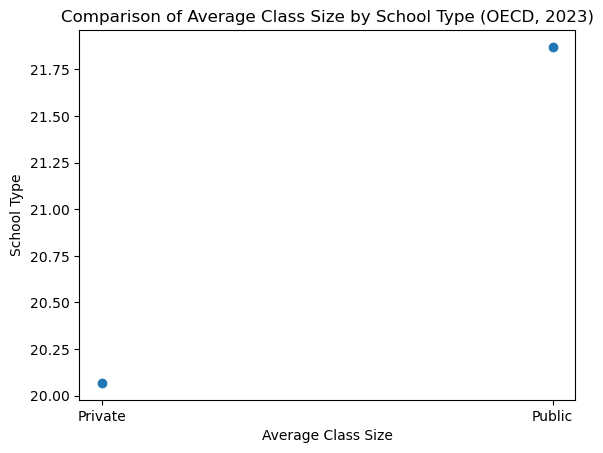

In [48]:
plt.figure()
plt.scatter(
    tidy_data["School_Type"],
    tidy_data["Average class size"]
    
)
plt.xlabel("Average Class Size")
plt.ylabel("School Type")
plt.title("Comparison of Average Class Size by School Type (OECD, 2023)")
plt.show()


### Combined Data Visualization 
- The first combined visualization presents boxplots of exam score distributions by school type, using student-level data from Project 1. The plot shows that both public and private schools have similar median exam scores, with substantial overlap in their distributions. However, the public school distribution exhibits a slightly wider spread and more high-end outliers, indicating greater variability in exam performance among public school students.

- The second visualization integrates the Project 1 exam score data with the OECD API data on average class size. This bar chart compares the average exam score and average class size for public and private schools. While average exam scores are similar across school types, public schools are associated with a larger average class size. This comparison suggests that differences in classroom structure may coexist with relatively similar average performance outcomes. Although this analysis does not establish causality, it highlights how external contextual factors such as class size can provide additional insight when interpreting patterns in student performance.

In [49]:
merge_df =pd.merge(df, tidy_data, how= 'left', on = 'School_Type')
merge_df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Type of educational institution,Average class size
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Public,Positive,3,No,High School,Near,Male,67,Public educational institutions,21.869572
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Public,Negative,4,No,College,Moderate,Female,61,Public educational institutions,21.869572
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Public,Neutral,4,No,Postgraduate,Near,Male,74,Public educational institutions,21.869572
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,Public,Negative,4,No,High School,Moderate,Male,71,Public educational institutions,21.869572
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,Public,Neutral,4,No,College,Near,Female,70,Public educational institutions,21.869572


<Figure size 640x480 with 0 Axes>

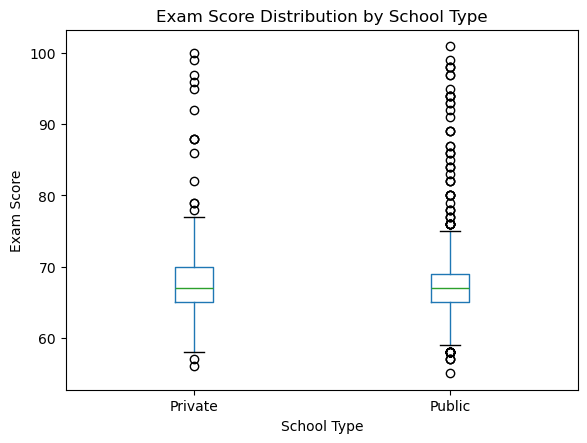

In [50]:
plt.figure()
merge_df.boxplot(
    column="Exam_Score",
    by="School_Type",
    grid=False
)

plt.title("Exam Score Distribution by School Type")
plt.suptitle("")  # removes automatic pandas title
plt.xlabel("School Type")
plt.ylabel("Exam Score")
plt.show()

<Figure size 640x480 with 0 Axes>

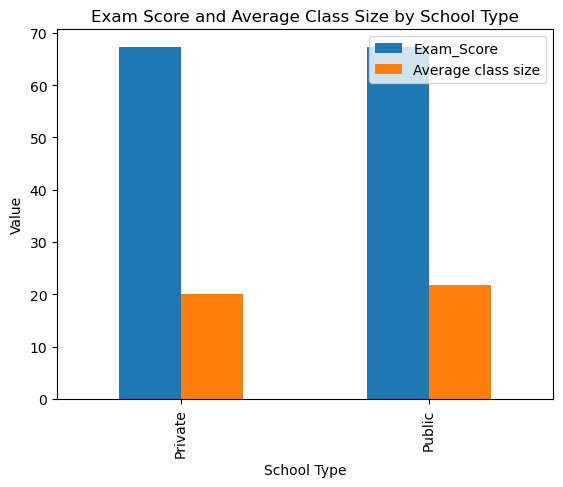

In [51]:
plt.figure()

(
    merge_df
    .groupby("School_Type")[["Exam_Score", "Average class size"]]
    .mean()
    .plot(kind="bar")
)

plt.xlabel("School Type")
plt.ylabel("Value")
plt.title("Exam Score and Average Class Size by School Type")
plt.show()

### Next Steps and Hypothesis

In Project 1, I hypothesized that student performance may be influenced by factors beyond study time, such as school type. Additionally, some omitted factors correlated with school type may also affect exam outcomes, one of which is average class size. The combined analysis largely supports this expectation, although differences in average exam scores between school types are modest and their distributions overlap substantially. Incorporating OECD data on average class size provides important context for these results. Public schools are associated with larger average class sizes than private schools, which may contribute to greater variability in student performance observed in public institutions. However, the similarity in average exam scores suggests that class size alone does not fully explain performance differences. Future analyses could examine how class size interacts with instructional quality, resources, or student demographics. Overall, integrating external data strengthens the original hypothesis by placing student performance within broader educational structures.